Clustering methods to be used:
- KMeans
- HDBScan

# Setup

In [ ]:
# Libraries and setup

# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Sentence embeddings
!pip install -U sentence-transformers
from sentence_transformers import SentenceTransformer

# Clustering algorithms
from sklearn.cluster import KMeans

!pip install hdbscan
import hdbscan

# Preprocessing
from sklearn.preprocessing import normalize, LabelEncoder

# Evaluation metrics
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    confusion_matrix,
    classification_report
)

# Reproducibility

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Dimensionality reduction
!pip install umap-learn
import umap.umap_ as umap

In [3]:
# Load dataset

file_path = "/content/corpus.tsv"

df = pd.read_csv(file_path, sep="\t", header=None)
df.columns = ["text", "split", "label"]
df = df.drop(columns=["split"])

# Preview dataset
df.head()


,text,label
0,broadband ahead join internet fast accord offi...,tech
1,plan share sale owner technology dominate inde...,business
2,mobile rack mobile phone celebrate anniversary...,tech
3,launch reconstruction drive appeal peace natio...,business
4,buy giant profit soar acquisition big firm tax...,business


In [4]:
# Convert text column to list format

texts = df["text"].astype(str).tolist()

# Preview first examples
print(texts[:3])


['broadband ahead join internet fast accord official figure number business connect jump report broadband connection end compare nation rank world telecom body election campaign ensure affordable high speed net access american accord report broadband increasingly popular research shopping download music watch video total number business broadband rise end compare hook broadband subscriber line technology ordinary phone line support high data speed cable lead account line broadband phone line connection accord figure', 'plan share sale owner technology dominate index plan sell share public list market operate accord document file stock market plan raise sale observer step close full public icon technology boom recently pour cold water suggestion company sell share private technically public stock start trade list equity trade money sale investor buy share private filing document share technology firm company high growth potential symbol internet telecom boom bubble burst recovery fortun

In [5]:
# Load sentence transformer model

model = SentenceTransformer("all-MiniLM-L6-v2")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
# Generate embeddings

embeddings = model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(embeddings.shape)


Batches:   0%|          | 0/70 [00:00<?, ?it/s]

(2225, 384)


In [10]:
# Normalise embeddings for similarity calculations

embeddings_norm = normalize(embeddings, norm="l2")


Labels to evaluate

In [13]:
# Store true labels

true_labels = df["label"]


In [14]:
# Check available label categories

true_labels.unique()


array(['tech', 'business', 'entertainment', 'sport', 'politics'],
      dtype=object)

In [15]:
# Encode labels into numeric format

le = LabelEncoder()
true_labels_encoded = le.fit_transform(true_labels)

# Display label mapping
print(list(le.classes_))


['business', 'entertainment', 'politics', 'sport', 'tech']


# **KMeans**

In [16]:
# KMeans clustering

k = 5

kmeans = KMeans(
    n_clusters=k,
    random_state=RANDOM_STATE,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(embeddings_norm)

print(kmeans_labels[:10])


[1 4 1 4 4 0 3 0 4 1]


In [17]:
# Evaluate KMeans clustering performance

ari = adjusted_rand_score(true_labels_encoded, kmeans_labels)
nmi = normalized_mutual_info_score(true_labels_encoded, kmeans_labels)
sil = silhouette_score(embeddings_norm, kmeans_labels)

print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"Silhouette Score: {sil:.4f}")


ARI: 0.8659
NMI: 0.8310
Silhouette Score: 0.0822


KMeans cluster → label mapping:
{0: 'entertainment', 1: 'tech', 2: 'politics', 3: 'sport', 4: 'business'}


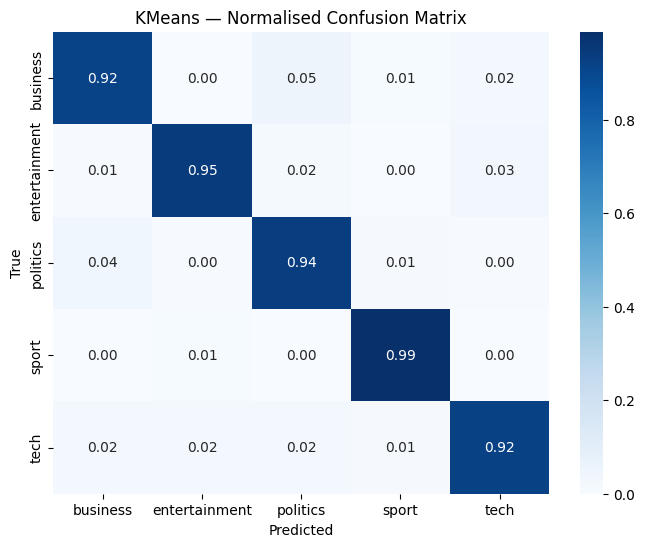

In [18]:
# KMeans confusion matrix

labels = ["business", "entertainment", "politics", "sport", "tech"]

# Build majority-vote mapping:
# cluster integer -> label name
kmeans_cluster_to_label = {}

for cluster_id in range(5):
    mask = kmeans_labels == cluster_id
    majority = true_labels[mask].mode()[0]
    kmeans_cluster_to_label[cluster_id] = majority

print("KMeans cluster → label mapping:")
print(kmeans_cluster_to_label)

# Map cluster predictions to label names
kmeans_predicted = pd.Series(kmeans_labels).map(kmeans_cluster_to_label)

# Create normalised confusion matrix
cm_kmeans = confusion_matrix(
    true_labels,
    kmeans_predicted,
    labels=labels,
    normalize="true"
)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_kmeans,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("KMeans — Normalised Confusion Matrix")

plt.show()


# **HDBScan**

In [19]:
# HDBSCAN clustering

hdb = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=7,
    metric="euclidean"
)

hdb_labels = hdb.fit_predict(embeddings_norm)

print(hdb_labels[:20])


[-1 -1 -1  0 -1 -1  1 -1  0 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1]


In [20]:
# Calculate noise ratio

noise_ratio = sum(hdb_labels == -1) / len(hdb_labels)

print(noise_ratio)


0.7892134831460674


In [21]:
# Remove noise points for evaluation

mask = hdb_labels != -1

filtered_labels = hdb_labels[mask]
filtered_true = true_labels_encoded[mask]
filtered_embeddings = embeddings_norm[mask]

print("Remaining points:", len(filtered_labels))


Remaining points: 469


In [22]:
# Inspect HDBSCAN cluster statistics

print("Unique labels:", np.unique(hdb_labels))
print("Noise points:", sum(hdb_labels == -1))

print(
    "Num clusters:",
    len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
)


Unique labels: [-1  0  1]
Noise points: 1756
Num clusters: 2


In [23]:
# Evaluate HDBSCAN clustering performance

ari_hdb = adjusted_rand_score(filtered_true, filtered_labels)
nmi_hdb = normalized_mutual_info_score(filtered_true, filtered_labels)

# Silhouette score only valid if more than one cluster exists
if len(set(filtered_labels)) > 1:
    sil_hdb = silhouette_score(filtered_embeddings, filtered_labels)
else:
    sil_hdb = -1

print(f"HDBSCAN ARI: {ari_hdb:.4f}")
print(f"HDBSCAN NMI: {nmi_hdb:.4f}")
print(f"HDBSCAN Silhouette: {sil_hdb:.4f}")


HDBSCAN ARI: 0.3268
HDBSCAN NMI: 0.5450
HDBSCAN Silhouette: 0.1374


HDBSCAN cluster → label mapping:
{np.int64(0): 'politics', np.int64(1): 'sport'}

Note: only 469/2225 docs assigned (21.1% coverage)


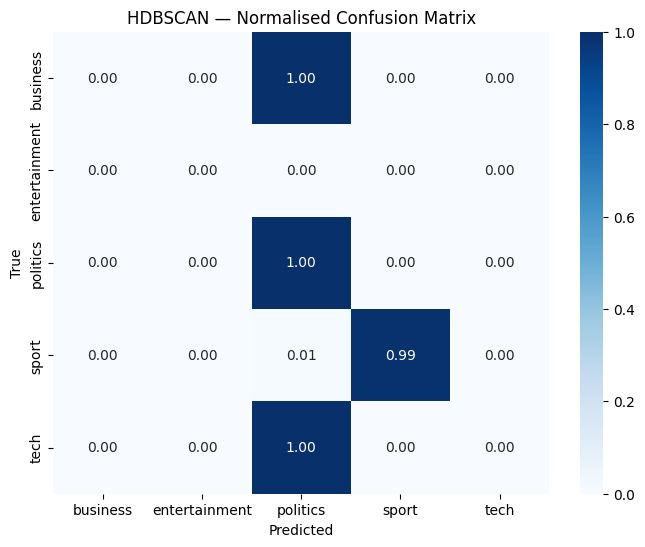

In [24]:
# HDBSCAN confusion matrix


# Work only on non-outlier points
mask = hdb_labels != -1

hdb_true = true_labels[mask].reset_index(drop=True)
hdb_pred_raw = filtered_labels

# Majority-vote mapping for clusters
hdb_cluster_to_label = {}

for cluster_id in np.unique(hdb_pred_raw):
    majority = hdb_true[hdb_pred_raw == cluster_id].mode()[0]
    hdb_cluster_to_label[cluster_id] = majority

print("HDBSCAN cluster → label mapping:")
print(hdb_cluster_to_label)

print(
    f"\nNote: only {len(hdb_true)}/2225 docs assigned "
    f"({len(hdb_true)/2225:.1%} coverage)"
)

# Map cluster IDs to label names
hdb_predicted = pd.Series(hdb_pred_raw).map(hdb_cluster_to_label)

# Create normalised confusion matrix
cm_hdb = confusion_matrix(
    hdb_true,
    hdb_predicted,
    labels=labels,
    normalize="true"
)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_hdb,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("HDBSCAN — Normalised Confusion Matrix")

plt.show()


# **HDBScan** + UMAP

In [26]:
# Reduce high-dimensional embeddings before clustering

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_STATE
)

embeddings_umap = umap_model.fit_transform(embeddings_norm)

print("Original shape:", embeddings_norm.shape)
print("Reduced shape:", embeddings_umap.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Original shape: (2225, 384)
Reduced shape: (2225, 5)


In [27]:
# Run HDBSCAN on UMAP-reduced embeddings

hdb_umap = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=7,
    metric="euclidean"
)

hdb_umap_labels = hdb_umap.fit_predict(embeddings_umap)

print(hdb_umap_labels[:20])

[2 5 2 5 5 8 4 7 5 2 5 8 6 8 5 5 5 8 4 6]


In [28]:
# Remove noise points before evaluation

mask_umap = hdb_umap_labels != -1

filtered_labels_umap = hdb_umap_labels[mask_umap]
filtered_true_umap = true_labels_encoded[mask_umap]
filtered_embeddings_umap = embeddings_umap[mask_umap]

print("Remaining points:", len(filtered_labels_umap))

Remaining points: 2193


In [29]:
# Inspect cluster statistics

print("Unique labels:", np.unique(hdb_umap_labels))
print("Noise points:", sum(hdb_umap_labels == -1))

print(
    "Num clusters:",
    len(set(hdb_umap_labels)) - (1 if -1 in hdb_umap_labels else 0)
)

Unique labels: [-1  0  1  2  3  4  5  6  7  8]
Noise points: 32
Num clusters: 9


In [30]:
# Evaluate UMAP + HDBSCAN performance

ari_umap = adjusted_rand_score(
    filtered_true_umap,
    filtered_labels_umap
)

nmi_umap = normalized_mutual_info_score(
    filtered_true_umap,
    filtered_labels_umap
)

# Silhouette score requires more than one cluster
if len(set(filtered_labels_umap)) > 1:
    sil_umap = silhouette_score(
        filtered_embeddings_umap,
        filtered_labels_umap
    )
else:
    sil_umap = -1

print(f"UMAP + HDBSCAN ARI: {ari_umap:.4f}")
print(f"UMAP + HDBSCAN NMI: {nmi_umap:.4f}")
print(f"UMAP + HDBSCAN Silhouette: {sil_umap:.4f}")

UMAP + HDBSCAN ARI: 0.7147
UMAP + HDBSCAN NMI: 0.7413
UMAP + HDBSCAN Silhouette: 0.6083


UMAP + HDBSCAN cluster -> label mapping:
{np.int64(0): 'sport', np.int64(1): 'sport', np.int64(2): 'tech', np.int64(3): 'sport', np.int64(4): 'sport', np.int64(5): 'business', np.int64(6): 'politics', np.int64(7): 'entertainment', np.int64(8): 'entertainment'}


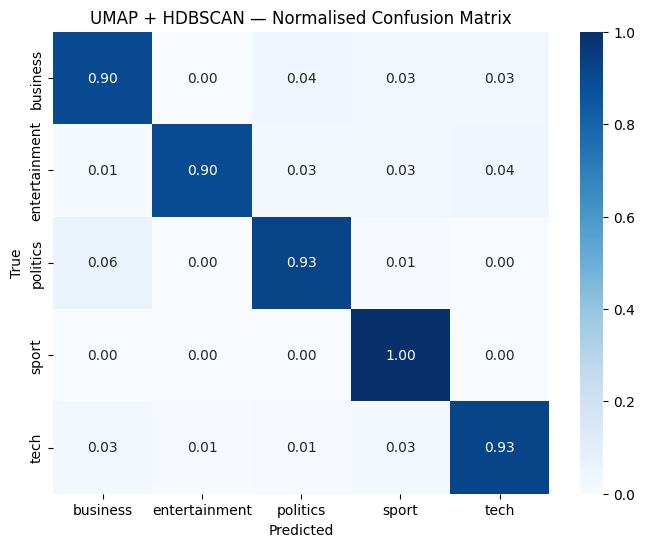

In [32]:
# UMAP + HDBSCAN confusion matrix

labels = ["business", "entertainment", "politics", "sport", "tech"]

# Keep only non-noise points
mask_umap = hdb_umap_labels != -1

hdb_umap_true = true_labels[mask_umap].reset_index(drop=True)
hdb_umap_pred_raw = filtered_labels_umap

# Majority-vote mapping
hdb_umap_cluster_to_label = {}

for cluster_id in np.unique(hdb_umap_pred_raw):
    majority = hdb_umap_true[
        hdb_umap_pred_raw == cluster_id
    ].mode()[0]

    hdb_umap_cluster_to_label[cluster_id] = majority

print("UMAP + HDBSCAN cluster -> label mapping:")
print(hdb_umap_cluster_to_label)

# Map cluster IDs to label names
hdb_umap_predicted = pd.Series(
    hdb_umap_pred_raw
).map(hdb_umap_cluster_to_label)

# Build confusion matrix
cm_hdb_umap = confusion_matrix(
    hdb_umap_true,
    hdb_umap_predicted,
    labels=labels,
    normalize="true"
)

# Plot matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_hdb_umap,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("UMAP + HDBSCAN — Normalised Confusion Matrix")

plt.show()